# Text Classification with Classical Machine Learning

## 📚 Learning Objectives

By completing this notebook, you will:
- Turn raw text into numeric features with **TF-IDF**
- Train **two** text classifiers — Naive Bayes and Logistic Regression — and **compare** them
- Evaluate with a held-out test set **and** cross-validation
- See, measured live, **why tiny datasets give unreliable evaluations**

## 🔗 Where this fits

**Builds on:** Course 04 (AIAT 114) — Unit 3, lessons 01 and 05 (logistic regression, Naive Bayes) and Unit 2, lesson 01 (cross-validation) — the same classifiers and the same evaluation, now on TF-IDF text features.

**Used later in:** Course 07 — Unit 5, whose bias audit inspects classifiers built this way.

---


## 🌍 Why this matters: the essay that killed most spam

In August 2002 Paul Graham published *A Plan for Spam* (<https://www.paulgraham.com/spam.html>), describing
exactly the pipeline in this notebook: turn each email into word features, learn from a corpus of spam and
a corpus of legitimate mail how spam-indicative each word is, and combine those word probabilities with
Bayes' rule. His reported result: **"we now miss less than 5 per 1000 spams, with 0 false positives"** —
roughly 99.5% of spam caught, and, in his test set, no legitimate mail wrongly binned. The academic version
came first (Sahami, Dumais, Heckerman & Horvitz, *A Bayesian Approach to Filtering Junk E-Mail*, AAAI-98
workshop), but Graham's essay is what put Bayesian filters into SpamAssassin, mainstream mail clients and
essentially every inbox within a couple of years.

Naive Bayes over word counts — the same `MultinomialNB` you are about to fit — is one of the highest
value-per-line-of-code techniques in this whole diploma.

**What goes wrong without this lesson.** The alternative to a learned classifier is a hand-written rule
list: block "FREE!!!", block "viagra", block senders with three exclamation marks. Rules do not survive
contact with an adversary — spammers rewrite around them within hours — and every new rule quietly breaks
an old one. A learned classifier is retrained on new data instead of being patched by hand.

**The same shape, other domains:** routing support tickets to the right department; sorting 911 call
descriptions by service type; flagging insurance claims for manual review; triaging Arabic customer
complaints by product line.

## 📥 Inputs & 📤 Outputs

**Inputs:** 32 short movie reviews written into this notebook (16 positive, 16 negative) — no downloads.

**Outputs:** a TF-IDF feature matrix, accuracy and per-class metrics for two classifiers, cross-validation
scores, and a measured demonstration of small-dataset instability.

---

## Part 1: From Text to Numbers — TF-IDF

Classifiers need numeric inputs, so each document becomes a vector of word scores. **TF-IDF** (Term
Frequency × Inverse Document Frequency) scores a word highly in a document when it appears **often in that
document** (TF) but **rarely across the other documents** (IDF). Words that appear everywhere — and generic
stop words like "the" — get little or no weight, so the surviving features are the words that actually
distinguish documents. This is the workhorse text representation for classical ML.


In [1]:
# Build a small labeled dataset and turn the text into numbers with TF-IDF.
# Classifiers cannot read words — TF-IDF gives each review a numeric vector that
# scores a word highly when it is frequent HERE but rare across ALL reviews.

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# A small labeled dataset: 16 positive and 16 negative movie reviews
positive_reviews = [
    "This movie is amazing and wonderful",
    "I love this film, it's fantastic and fun",
    "Great acting and a wonderful story",
    "Excellent film with great cinematography",
    "A wonderful, fun and heartwarming movie",
    "Brilliant, amazing performances by the cast",
    "I love this movie, highly recommended",
    "One of the best films of the year, amazing",
    "Beautiful story, excellent acting, great fun",
    "Fantastic soundtrack and a great story",
    "A brilliant film full of wonderful moments",
    "Amazing direction and excellent acting, loved it",
    "Fun, fantastic and beautifully made",
    "The best movie this year, wonderful acting",
    "Loved the story, great film, highly recommended",
    "The plot is slow at times, but the acting is wonderful and the ending is amazing",
]
negative_reviews = [
    "Terrible movie, very boring",
    "Worst film I have ever seen, awful",
    "Poor quality, boring and not recommended",
    "Boring and slow from start to finish",
    "Awful acting and a terrible plot",
    "A complete waste of time, very poor",
    "Disappointing film with terrible dialogue",
    "Dull story, flat characters, boring",
    "Bad editing and a confusing, awful plot",
    "I regret watching this boring mess",
    "Cheap effects, horrible pacing, terrible",
    "Painfully slow, dull and forgettable",
    "The worst acting I have seen, awful film",
    "Terrible pacing and a dull, bad story",
    "Poor script, boring scenes, disappointing",
    "A great cast completely wasted on a boring, terrible script",
]
documents = positive_reviews + negative_reviews
labels = ["positive"] * len(positive_reviews) + ["negative"] * len(negative_reviews)
print(f"Dataset: {len(documents)} reviews "
      f"({labels.count('positive')} positive / {labels.count('negative')} negative)")

# TF-IDF feature extraction
vectorizer = TfidfVectorizer(stop_words="english")
X = vectorizer.fit_transform(documents)
features = vectorizer.get_feature_names_out()

print(f"\nTF-IDF matrix: {X.shape[0]} documents x {X.shape[1]} features (one per distinct word)")
print(f"Sample features: {sorted(features)[:10]} ...")

# Peek at one document's strongest features
doc0 = X[0].toarray().ravel()
top = np.argsort(doc0)[::-1][:4]
print(f"\nDocument 1: {documents[0]!r}")
print("Its highest TF-IDF features:", [(str(features[i]), round(float(doc0[i]), 3)) for i in top])

Dataset: 32 reviews (16 positive / 16 negative)

TF-IDF matrix: 32 documents x 64 features (one per distinct word)
Sample features: ['acting', 'amazing', 'awful', 'bad', 'beautiful', 'beautifully', 'best', 'boring', 'brilliant', 'cast'] ...

Document 1: 'This movie is amazing and wonderful'
Its highest TF-IDF features: [('amazing', 0.588), ('movie', 0.588), ('wonderful', 0.555), ('year', 0.0)]


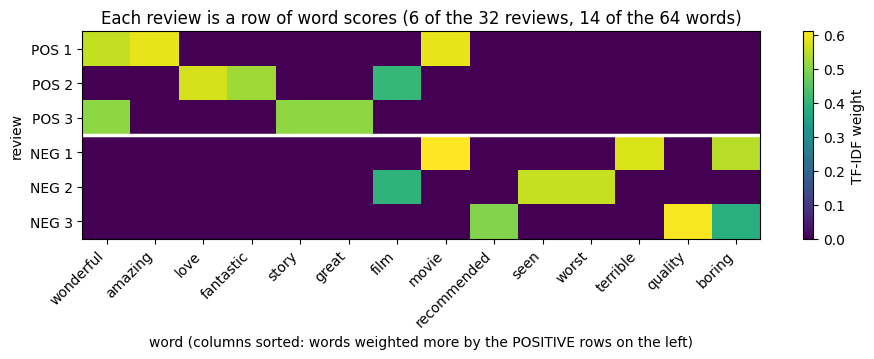

Empty (zero) cells in the picture above: 79%
Empty cells in the full 32 x 64 TF-IDF matrix: 93%


In [2]:
# SEE the feature matrix: TF-IDF turns each review into a row of word scores.
# WHY a picture: "32 x 64 matrix" is an abstraction; the grid below shows what is
# actually stored — mostly zeros, with a few lit cells that carry the meaning.

import matplotlib.pyplot as plt

# Take the first three positive and first three negative reviews (rows of X above).
rows = [0, 1, 2, 16, 17, 18]
row_names = ["POS 1", "POS 2", "POS 3", "NEG 1", "NEG 2", "NEG 3"]
sub = X[rows].toarray()

# Keep the 14 words that carry the most weight in these six reviews, and sort the
# columns so words weighted more by the POSITIVE rows sit on the left.
keep = np.argsort(sub.sum(axis=0))[::-1][:14]
keep = keep[np.argsort(sub[:3, keep].mean(0) - sub[3:, keep].mean(0))[::-1]]
M = sub[:, keep]

fig, ax = plt.subplots(figsize=(9.5, 3.7))
im = ax.imshow(M, cmap="viridis", aspect="auto", vmin=0)
ax.set_xticks(range(len(keep)))
ax.set_xticklabels(features[keep], rotation=45, ha="right")
ax.set_yticks(range(len(rows)))
ax.set_yticklabels(row_names)
ax.set_xlabel("word (columns sorted: words weighted more by the POSITIVE rows on the left)")
ax.set_ylabel("review")
ax.set_title(f"Each review is a row of word scores "
             f"({len(rows)} of the {X.shape[0]} reviews, {len(keep)} of the {X.shape[1]} words)")
ax.axhline(2.5, color="white", lw=2.5)          # the line between the two classes
fig.colorbar(im, ax=ax, label="TF-IDF weight")
plt.tight_layout()
plt.show()

# Sparsity, measured — the dark cells are not decoration, they are most of the matrix.
print(f"Empty (zero) cells in the picture above: {(M == 0).mean():.0%}")
print(f"Empty cells in the full {X.shape[0]} x {X.shape[1]} TF-IDF matrix: "
      f"{1 - X.nnz / (X.shape[0] * X.shape[1]):.0%}")

**Read the picture.** Every row is one review, every column one word, and the colour is that word's
TF-IDF weight in that review. Three things to see:

- **Most of the grid is dark.** The printed percentages say how much: a review uses a handful of the 64
  words and scores 0 on all the rest. That is what "sparse matrix" means, and it is why TF-IDF scales to
  millions of documents.
- **The lit cells cluster by class.** The three positive rows light up the left-hand columns
  (*wonderful, amazing, love, fantastic*), the three negative rows the right-hand ones
  (*worst, terrible, quality, boring*). That visible separation is the whole reason a classifier can work
  here — and a warning that this dataset is unusually easy.
- **The middle columns are shared.** *film* and *movie* are lit on both sides of the white line, so within
  these six reviews they separate nothing. Watch *movie* in the next figure anyway.

One column is worth arguing about: **recommended** sits on the negative side, because NEG 3 is
*"Poor quality, boring and **not recommended**"*. TF-IDF kept *recommended* and threw the *not* away.
Hold that thought until "⚠️ Where this breaks".

## Part 2: Train and Compare Two Classifiers

Quick refreshers:

- **Train/test split**: we hold out 25% of documents the models never see during training, so the accuracy
  we report measures *generalization*, not memorization. `stratify` keeps the class balance in both halves.
- **Multinomial Naive Bayes**: learns how likely each word is inside each class, then multiplies those
  likelihoods (assuming words are independent — "naive", but famously effective on text counts).
- **Logistic Regression**: learns one weight per word — positive weights push toward one class, negative
  toward the other — and squashes the weighted sum into a probability.

We evaluate both with the same held-out test set, and then with **8-fold cross-validation** (train/evaluate
8 times on different splits and average), which uses the small dataset more efficiently than a single split.


In [3]:
# Train and compare two classic text classifiers on the SAME features.
# Naive Bayes and Logistic Regression are the standard first models for text:
# fast, strong baselines you should always try before anything deep.

X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.25, random_state=42, stratify=labels
)
print(f"Training on {X_train.shape[0]} reviews, testing on {X_test.shape[0]} held-out reviews\n")

# Two candidate models trained on identical TF-IDF features — a fair head-to-head.
classifiers = {
    "Multinomial Naive Bayes": MultinomialNB(),
    "Logistic Regression": LogisticRegression(max_iter=1000),
}

results = {}
# Fit on the training split, score on held-out data, and cross-validate for stability.
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    predictions = clf.predict(X_test)
    holdout_acc = accuracy_score(y_test, predictions)
    cv_scores = cross_val_score(clf, X, labels, cv=8)
    results[name] = (holdout_acc, cv_scores.mean(), cv_scores.std(), predictions)

    print("=" * 64)
    print(name)
    print("=" * 64)
    for true, pred in zip(y_test, predictions):
        mark = "✓" if true == pred else "✗"
        print(f"  true: {true:8s}  predicted: {pred:8s}  {mark}")
    print(f"  Held-out accuracy:        {holdout_acc:.1%}")
    print(f"  8-fold CV accuracy:       {cv_scores.mean():.1%} (+/- {cv_scores.std():.1%})")
    print()

# Detailed per-class metrics for the first classifier
nb_pred = results["Multinomial Naive Bayes"][3]
print("Per-class metrics (Naive Bayes, held-out test set):")
print(classification_report(y_test, nb_pred))

# Computed comparison
(nb_h, nb_cv, _, _) = results["Multinomial Naive Bayes"]
(lr_h, lr_cv, _, _) = results["Logistic Regression"]
if abs(nb_cv - lr_cv) < 1e-9:
    print(f"Comparison: both classifiers score identically here (CV {nb_cv:.1%}).")
elif nb_cv > lr_cv:
    print(f"Comparison: Naive Bayes wins on CV ({nb_cv:.1%} vs {lr_cv:.1%}).")
else:
    print(f"Comparison: Logistic Regression wins on CV ({lr_cv:.1%} vs {nb_cv:.1%}).")
print("On real, larger datasets the two often differ more; on this small clean dataset")
print("read the comparison from the numbers above, not from folklore.")

Training on 24 reviews, testing on 8 held-out reviews

Multinomial Naive Bayes
  true: positive  predicted: positive  ✓
  true: positive  predicted: positive  ✓
  true: negative  predicted: negative  ✓
  true: negative  predicted: negative  ✓
  true: positive  predicted: positive  ✓
  true: positive  predicted: positive  ✓
  true: negative  predicted: negative  ✓
  true: negative  predicted: negative  ✓
  Held-out accuracy:        100.0%
  8-fold CV accuracy:       100.0% (+/- 0.0%)

Logistic Regression
  true: positive  predicted: positive  ✓
  true: positive  predicted: positive  ✓
  true: negative  predicted: negative  ✓
  true: negative  predicted: negative  ✓
  true: positive  predicted: positive  ✓
  true: positive  predicted: positive  ✓
  true: negative  predicted: negative  ✓
  true: negative  predicted: negative  ✓
  Held-out accuracy:        100.0%
  8-fold CV accuracy:       100.0% (+/- 0.0%)

Per-class metrics (Naive Bayes, held-out test set):
              precision    re

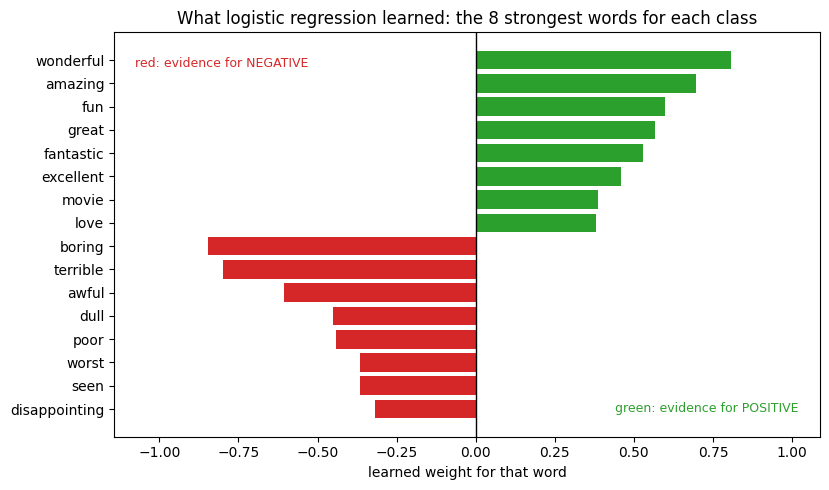

'movie': weight +0.39  (appears in 4 positive and 1 negative reviews)
'seen': weight -0.37  (appears in 0 positive and 2 negative reviews)


In [4]:
# SEE what the trained model actually learned: one weight per word.
# WHY it matters: this is the readable part of a linear model — you can put these
# bars in front of a stakeholder, which is something no deep model gives you free.

import matplotlib.pyplot as plt

# Refit logistic regression on ALL 32 reviews so the weights use every example.
lr_full = LogisticRegression(max_iter=1000).fit(X, labels)
coef = lr_full.coef_[0]           # classes_ = ['negative', 'positive'] -> + means "positive"

k = 8
top_pos = np.argsort(coef)[::-1][:k]      # strongest evidence for POSITIVE
top_neg = np.argsort(coef)[:k]            # strongest evidence for NEGATIVE
idx = np.concatenate([top_neg[::-1], top_pos[::-1]])
vals = coef[idx]

fig, ax = plt.subplots(figsize=(8.4, 5.0))
ax.barh(range(len(idx)), vals, color=["tab:red" if v < 0 else "tab:green" for v in vals])
ax.set_yticks(range(len(idx)))
ax.set_yticklabels(features[idx])
ax.axvline(0, color="black", lw=1)
ax.set_xlim(vals.min() * 1.35, vals.max() * 1.35)
ax.set_xlabel("learned weight for that word")
ax.set_title(f"What logistic regression learned: the {k} strongest words for each class")
ax.text(0.03, 0.94, "red: evidence for NEGATIVE", transform=ax.transAxes,
        color="tab:red", fontsize=9, va="top")
ax.text(0.97, 0.06, "green: evidence for POSITIVE", transform=ax.transAxes,
        color="tab:green", fontsize=9, ha="right")
plt.tight_layout()
plt.show()

# Not every strong word is a sentiment word — check the counts yourself.
for w in ("movie", "seen"):
    j = list(features).index(w)
    in_pos = sum(w in r.lower() for r in positive_reviews)
    in_neg = sum(w in r.lower() for r in negative_reviews)
    print(f"{w!r}: weight {coef[j]:+.2f}  (appears in {in_pos} positive and {in_neg} negative reviews)")

**Read the picture.** Each bar is one word's learned weight: bars to the right are evidence the review is
positive, bars to the left evidence it is negative, and length is how strongly the model leans on that word.

The top of each side is the vocabulary a human would have picked — *wonderful, amazing, fun* against
*boring, terrible, awful*. **That readability is the practical argument for keeping this baseline:** you can
show these bars to a client and defend a decision, which no deep model gives you for free.

Now look at the two that do not belong. *movie* is among the strongest **positive** words and *seen* among
the strongest **negative** ones — neither carries any sentiment. The counts printed under the figure explain
why: they simply happened to fall on one side in these 32 reviews. That is a spurious correlation seen from
the inside, and it is the first concrete reason to distrust the 100% score above.

### Reading the comparison you just ran

Two different learning algorithms, one identical feature matrix, one identical evaluation protocol — that
is a fair head-to-head, and in this run it came back a tie at the ceiling (both models 100% held-out
and 100% on 8-fold CV). The only conclusion those numbers support is
"**this dataset cannot tell these two models apart**", which is a statement about the data, not about the
models. Keep that distinction: a comparison that cannot separate its candidates has failed to measure
anything, however impressive the number printed next to it.

## 💬 Discuss

Both classifiers just scored 100% — on the held-out split *and* on 8-fold cross-validation. Argue with that.

1. Graham reported his result as "0 false positives", not as an accuracy. In a spam filter a false positive
   is a real email — a job offer, a bank alert — silently binned; a false negative is one more piece of junk
   in the inbox. Which error would you optimize against, and what would that decision do to the `precision`
   and `recall` columns printed above? Does your answer flip for a hospital triage classifier?
2. You show this 100% to a client as evidence the system is ready. What is the honest sentence you must say
   in the same breath? (Look at the shape of the matrix: 64 features from 32 short reviews.)
3. Naive Bayes assumes words are independent given the class — plainly false for language, where "highly"
   and "recommended" travel together. It works anyway. Does a model have to be *true* to be *useful*?
   Describe a situation where you would reject a model that works but whose assumptions are false.

## Part 3: Why Are These Scores So High? (And When Not to Trust a Score)

Look at the accuracies you just computed. They are high because this toy dataset is **easy**: positive
reviews reuse words like *amazing/wonderful/great*, negative ones reuse *boring/terrible/awful*, so TF-IDF
features separate the classes almost perfectly. Real-world text — sarcasm, mixed opinions, typos, topic
drift — is far messier, and scores like these should make you suspicious, not proud.

There is a second trap: **evaluation on tiny datasets is unstable**. To *measure* that instead of just
claiming it, the next cell shrinks the dataset to 8 reviews (2 test documents) and re-runs the identical
pipeline with five different random splits. Watch the "accuracy" swing. The grid it draws underneath shows *which* reviews were held out each time.


Same pipeline, but only 8 documents (2 in the test set), 5 different splits:
  split seed 0: accuracy = 100%
  split seed 1: accuracy = 100%
  split seed 2: accuracy = 100%
  split seed 3: accuracy = 0%
  split seed 4: accuracy = 0%

Accuracy across splits: min 0%, max 100%, mean 60%
Same data, same model — the score depends mostly on WHICH 2 documents landed in
the test set. With so few test samples, a single accuracy number is noise.
Lessons: (1) never trust an evaluation with a handful of test samples;
(2) prefer cross-validation on small data; (3) get more data when you can.


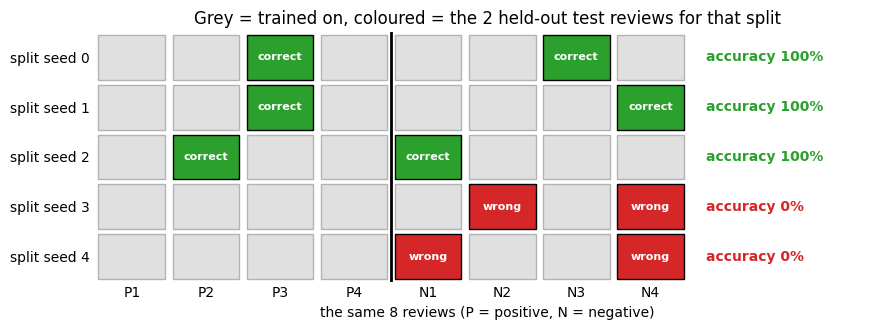

  seed 0: held out N3/P3   -> predicted ['negative', 'positive'], training half had 3 positive / 3 negative
  seed 1: held out N4/P3   -> predicted ['negative', 'positive'], training half had 3 positive / 3 negative
  seed 2: held out N1/P2   -> predicted ['negative', 'positive'], training half had 3 positive / 3 negative
  seed 3: held out N2/N4   -> predicted ['positive', 'positive'], training half had 4 positive / 2 negative
  seed 4: held out N1/N4   -> predicted ['positive', 'positive'], training half had 4 positive / 2 negative


In [5]:
# Stress test: rerun the same pipeline with only 8 documents to expose a trap.
# Tiny test sets make accuracy a lottery — this is the most common way beginners
# fool themselves about model quality.

import matplotlib.pyplot as plt

tiny_docs = positive_reviews[:4] + negative_reviews[:4]
tiny_labels = ["positive"] * 4 + ["negative"] * 4

print("Same pipeline, but only 8 documents (2 in the test set), 5 different splits:")
tiny_accs = []
runs = []          # keep WHICH documents were tested, so we can draw the splits below
# Same model, five different random train/test splits — watch the score jump around.
for seed in range(5):
    v = TfidfVectorizer(stop_words="english")
    Xt = v.fit_transform(tiny_docs)
    # Split the document INDICES (identical partition to splitting the matrix itself),
    # so we can show which reviews landed in the test set.
    tr, te = train_test_split(np.arange(len(tiny_docs)), test_size=0.25, random_state=seed)
    model = MultinomialNB().fit(Xt[tr], [tiny_labels[i] for i in tr])
    pred = model.predict(Xt[te])
    acc = accuracy_score([tiny_labels[i] for i in te], pred)
    tiny_accs.append(acc)
    runs.append((seed, tr, te, pred, acc))
    print(f"  split seed {seed}: accuracy = {acc:.0%}")

print(f"\nAccuracy across splits: min {min(tiny_accs):.0%}, max {max(tiny_accs):.0%}, "
      f"mean {np.mean(tiny_accs):.0%}")
print("Same data, same model — the score depends mostly on WHICH 2 documents landed in")
print("the test set. With so few test samples, a single accuracy number is noise.")
print("Lessons: (1) never trust an evaluation with a handful of test samples;")
print("(2) prefer cross-validation on small data; (3) get more data when you can.")

# Draw the five splits as five rows: one column per review, so "which 2 were tested"
# becomes something you can point at instead of something you have to imagine.
names = [f"P{i + 1}" for i in range(4)] + [f"N{i + 1}" for i in range(4)]
fig, ax = plt.subplots(figsize=(9.0, 3.4))
for seed, tr, te, pred, acc in runs:
    y = 4 - seed
    for i in range(len(tiny_docs)):
        if i in te:
            correct = pred[list(te).index(i)] == tiny_labels[i]
            ax.add_patch(plt.Rectangle((i + .05, y + .05), .9, .9, edgecolor="black",
                                       facecolor="tab:green" if correct else "tab:red"))
            ax.text(i + .5, y + .5, "correct" if correct else "wrong", ha="center", va="center",
                    color="white", fontsize=8, fontweight="bold")
        else:
            ax.add_patch(plt.Rectangle((i + .05, y + .05), .9, .9,
                                       facecolor="0.88", edgecolor="0.7"))
    ax.text(8.25, y + .5, f"accuracy {acc:.0%}", va="center", fontsize=10, fontweight="bold",
            color="tab:green" if acc == 1 else "tab:red")
ax.axvline(4, color="black", lw=2)          # the line between positive and negative reviews
ax.set_xlim(0, 10.6)
ax.set_ylim(0, 5)
ax.set_xticks([i + .5 for i in range(8)])
ax.set_xticklabels(names)
ax.set_yticks([4 - s + .5 for s in range(5)])
ax.set_yticklabels([f"split seed {s}" for s in range(5)])
ax.set_xlabel("the same 8 reviews (P = positive, N = negative)")
ax.set_title("Grey = trained on, coloured = the 2 held-out test reviews for that split")
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout()
plt.show()

# What the failing splits actually did, in words.
for seed, tr, te, pred, acc in runs:
    held = "/".join(names[i] for i in te)
    n_pos_train = sum(tiny_labels[i] == "positive" for i in tr)
    print(f"  seed {seed}: held out {held:7s} -> predicted {[str(p) for p in pred]}, "
          f"training half had {n_pos_train} positive / {len(tr) - n_pos_train} negative")

**Read the picture.** Five rows, five random splits of the *same* eight reviews. Grey cells were trained
on; the two coloured cells in each row are the reviews that were held out and tested; the black line
separates the positive reviews (P1-P4) from the negative ones (N1-N4).

Rows 0, 1 and 2 each held out one positive and one negative review, and scored 100%. Rows 3 and 4 held out
**two negative reviews and no positive one** — and scored 0%. The printout under the figure shows what
happened: with both held-out reviews negative, the training half was left 4-positive against 2-negative, and
Naive Bayes answered "positive" to both test reviews.

Nothing about the model changed between those rows. The number we call "accuracy" was decided by which two
of eight documents happened to fall into the test column. **So does more data fix it?** The next cell
measures that instead of asserting it.

 reviews  test docs   worst   best    mean  spread (sd)
       8          2     50%   100%   91.7%        18.6
      16          4     50%   100%   88.3%        14.0


      24          6     67%   100%   97.8%         7.1
      32          8     88%   100%   99.6%         2.2


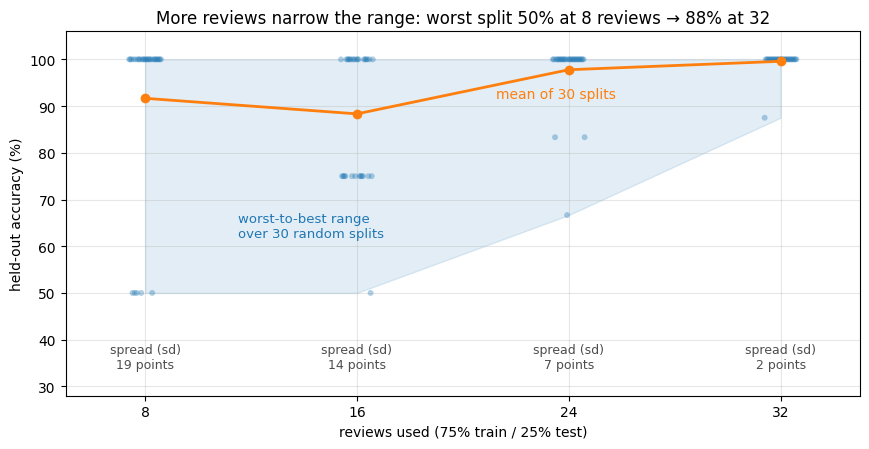

In [6]:
# Does more data fix the lottery? Measure it: run the same pipeline on 8, 16, 24
# and 32 reviews, 30 random splits each, and look at the SPREAD, not the average.
# Randomness is the subject of this experiment, so drawing random splits is the point.

import matplotlib.pyplot as plt

rng = np.random.default_rng(0)
sizes = [8, 16, 24, 32]
n_splits = 30

fig, ax = plt.subplots(figsize=(8.8, 4.6))
mean_acc, worst, best, spread = [], [], [], []
print(f"{'reviews':>8}{'test docs':>11}{'worst':>8}{'best':>7}{'mean':>8}{'spread (sd)':>13}")
for n in sizes:
    half = n // 2
    accs = []
    for r in range(n_splits):
        # Draw a balanced subset of the real reviews, then split it 75/25 as before.
        pos_i = rng.choice(len(positive_reviews), half, replace=False)
        neg_i = rng.choice(len(negative_reviews), half, replace=False)
        docs = [positive_reviews[i] for i in pos_i] + [negative_reviews[i] for i in neg_i]
        labs = ["positive"] * half + ["negative"] * half
        Xn = TfidfVectorizer(stop_words="english").fit_transform(docs)
        Xtr, Xte, ytr, yte = train_test_split(Xn, labs, test_size=0.25,
                                              random_state=int(r), stratify=labs)
        accs.append(accuracy_score(yte, MultinomialNB().fit(Xtr, ytr).predict(Xte)))
    a = np.array(accs) * 100
    mean_acc.append(a.mean()); worst.append(a.min()); best.append(a.max()); spread.append(a.std())
    # One dot per split, spread sideways so overlapping results stay countable.
    ax.scatter(n + np.linspace(-.6, .6, n_splits), a, s=18, color="tab:blue",
               alpha=.35, edgecolors="none", zorder=3)
    ax.annotate(f"spread (sd)\n{a.std():.0f} points", (n, 34), ha="center", fontsize=9, color="0.3")
    print(f"{n:>8}{int(n * .25):>11}{a.min():>7.0f}%{a.max():>6.0f}%{a.mean():>7.1f}%{a.std():>12.1f}")

ax.fill_between(sizes, worst, best, color="tab:blue", alpha=.13, zorder=1)
ax.plot(sizes, mean_acc, "o-", color="tab:orange", lw=2, zorder=4)
ax.text(23.5, mean_acc[2] - 6, f"mean of {n_splits} splits", color="tab:orange", fontsize=10, ha="center")
ax.text(11.5, 62, f"worst-to-best range\nover {n_splits} random splits",
        color="tab:blue", fontsize=9.5)
ax.set_xticks(sizes)
ax.set_xlim(5, 35)
ax.set_ylim(28, 106)
ax.set_xlabel("reviews used (75% train / 25% test)")
ax.set_ylabel("held-out accuracy (%)")
ax.set_title(f"More reviews narrow the range: worst split {worst[0]:.0f}% at {sizes[0]} reviews "
             f"→ {worst[-1]:.0f}% at {sizes[-1]}")
ax.grid(alpha=.3)
plt.tight_layout()
plt.show()

**Read the picture.** Each blue dot is one held-out accuracy; there are 30 dots above every dataset size.
The shaded band runs from the worst split to the best one, and the orange line is the average.

The band is the point. At 8 reviews it stretches from the worst split to a perfect score — the same
lottery you just saw drawn cell by cell. As reviews are added the band closes from below, and the spread
printed under each column falls in the same direction (the exact numbers are in the table above the
figure). By 32 reviews the disagreement between splits is a couple of points.

Note what does **not** happen: the orange mean line is not a smooth climb — it dips at 16 reviews. Even the
average of 30 runs is unstable at these sizes. **What more data buys you here is not a higher score, it is
a score you can repeat** — and repeatability is what lets you claim one model beat another.

---

## ✅ Summary

**What you actually did here** (all numbers computed live above):

- Built TF-IDF features from 32 labeled reviews and inspected which words score highly
- Trained and **compared** Multinomial Naive Bayes and Logistic Regression, with a held-out test set,
  per-class precision/recall/F1, and 8-fold cross-validation
- Measured evaluation instability on a tiny 8-document dataset: the same pipeline's accuracy swung between
  the minimum and maximum you printed, purely from the random split

**Honest limitations:** the 32-review dataset is deliberately easy and vocabulary-separable, so the scores
here are near the ceiling; real sentiment data (you will meet some in the exercise) is much harder.

**Next:** `02_named_entity_recognition.ipynb` — extracting structured information with spaCy.


## ⚠️ Where this breaks

**Bag-of-words has no word order, so it has no negation and no sarcasm.** To TF-IDF, *"great cast,
terrible script"* and *"terrible cast, great script"* are the same document. This dataset deliberately
includes one mixed review in each class for that reason — and with only 8 held-out documents you cannot
tell from the printed output whether either of them was even tested.

**Two failure conditions visible in this notebook's own numbers:**
- The tiny-data run swung between **0% and 100%** accuracy across five random splits of the *same* eight
  documents. A single accuracy computed on a handful of test examples is noise, not evidence.
- 100% on the full set is a symptom, not an achievement: the two classes were written with almost disjoint
  vocabulary. When your test accuracy is perfect, suspect the dataset before you congratulate the model.

**The assumption that must hold:** tomorrow's text looks like today's training text. Spam violates this by
design — the sender is actively rewriting to evade you, which is concept drift under adversarial pressure —
which is why production filters retrain continuously and keep a human-labelled feedback loop.

**When to reach for something else:**
- Very few labels (a few hundred or fewer) → a **pretrained model used zero-shot** (Unit 4) will usually
  beat training your own from scratch.
- Meaning depends on order or negation, or you need per-example explanations → fine-tune a transformer
  (Unit 4) and accept the cost.
- The task is really keyword lookup → a maintained rule list is cheaper, auditable and instantly fixable.
  Not every text problem needs a model.

**A 2026 caution about evaluation itself.** It is now common to score text systems by asking a large model
to judge the outputs. That is a measurement instrument with its own bias and instability: see TrustJudge on
judge inconsistency ([arXiv:2509.21117](https://arxiv.org/abs/2509.21117)) and the reporting protocol in
[arXiv:2511.21140](https://arxiv.org/abs/2511.21140) before you present a judge score the way you would
present the accuracy above.

## 🔭 State of the field (2026)

Faced with this task today, most teams do not start by training anything. The first probe is a zero-shot
prompt to an instruction-tuned open model — no labels at all, and Arabic covered out of the box
([arXiv:2505.09388](https://arxiv.org/abs/2505.09388)); the second is embeddings from a downloaded encoder
with a small classifier on top ([arXiv:2506.05176](https://arxiv.org/abs/2506.05176)); fine-tuning comes
third, once the cheaper two have been measured and found wanting. TF-IDF plus logistic regression stayed on
that list for solid reasons: it trains in milliseconds, serves on a CPU with no GPU budget, exposes per-word
weights you can read to a stakeholder, and it is the number every heavier option has to beat before anyone
should pay for it.

So run this notebook as what it is — the baseline and the measuring stick. The harder 2026 lesson is not
which of the four options to pick, but that all four are compared on the same held-out set with the same
metric and the same honesty about how few test documents you have: a zero-shot model scored on eight
examples is exactly as much noise as the 0%-100% swing you produced above.


## 📚 References

Where these ideas come from — seminal work first, then a modern survey, then the 2025-2026 evaluation literature:

1. Salton, G., & Buckley, C. (1988). *Term-Weighting Approaches in Automatic Text Retrieval*. Information Processing & Management, 24(5), 513-523.
2. Jurafsky, D. & Martin, J. H. (2025). *Speech and Language Processing* (3rd ed. draft) — chapter on Naive Bayes, text classification, and sentiment. <https://web.stanford.edu/~jurafsky/slp3/>
3. Minaee, S., Kalchbrenner, N., Cambria, E., et al. (2021). *Deep Learning-Based Text Classification: A Comprehensive Review*. ACM Computing Surveys. [arXiv:2004.03705](https://arxiv.org/abs/2004.03705)
4. Wang, Y., Song, Y., Zhu, T., Zhang, X., Yu, Z., et al. (2025). *TrustJudge: Inconsistencies of LLM-as-a-Judge and How to Alleviate Them*. [arXiv:2509.21117](https://arxiv.org/abs/2509.21117) — read before you score any text system with another model.
5. Lee, C., Zeng, T., Jeong, J., Sohn, J.-y., & Lee, K. (2025). *How to Correctly Report LLM-as-a-Judge Evaluations*. ICML 2026. [arXiv:2511.21140](https://arxiv.org/abs/2511.21140) — bias correction and confidence intervals for judge-based numbers.
